# Azure Machine Learning — Deploying a Model to a Managed Online Endpoint

Azure Machine Learning (Azure ML) is Microsoft's managed ML platform. It organises models, datasets, compute, and deployments inside a **workspace** — a central resource group for all ML activities.

This notebook covers the full deployment flow using the `azure-ai-ml` SDK. All calls that require Azure credentials are wrapped in `try/except` so the notebook runs cleanly in any environment.

## 🔗 Where this fits

**Builds on:** Course 08 (AIAT 122) — Unit 5, lesson 01 "01 Model Optimization" — saving and reloading a trained model was called the foundation of every deployment there; an Azure ML workspace is that saved artifact registered as a versioned object, with an environment and an endpoint attached to it.


## 📰 Booking.com: a better offline score is not a better business

Booking.com's KDD 2019 paper on roughly **150 customer-facing machine-learning models** contains a finding that should change how you read every accuracy number in this course: **improvements in offline model performance did not reliably translate into business value.** Models that were clearly better on held-out data produced no measurable gain when they reached real users — and the only way the team found out was by putting both models in front of live traffic and measuring the outcome that actually mattered to the business.

That is exactly what the `blue` / `green` traffic split in section 8 is for. `endpoint.traffic = {'blue': 90, 'green': 10}` is not a deployment convenience. It is the mechanism by which a claim about a model becomes evidence about a business.

**What goes wrong without this lesson.** Without a stable endpoint and swappable deployments behind it, updating a model means editing the thing clients call — so every model change is also a client-facing change, every rollback is a redeploy, and there is no way to run the new model on 10% of traffic to find out whether the offline gain is real. Azure ML's endpoint/deployment split exists so that the URL can outlive the model.

## Learning Objectives

By the end of this notebook you will be able to:
1. Explain what an Azure ML workspace, online endpoint, and deployment are
2. Write and understand the scoring script pattern (`init()` and `run()`)
3. Register a model in the Azure ML model registry
4. Create an online endpoint and deploy a model to it
5. Invoke the endpoint and interpret the response

## 1. Azure ML Concepts

**Workspace** — the top-level Azure ML resource. Contains all assets: models, datasets, compute clusters, endpoints.

**Online Endpoint** — a stable HTTPS URL. Traffic arrives here. Think of it as the address for your service.

**Deployment** — the actual running infrastructure behind an endpoint. One endpoint can have multiple deployments with traffic splits (useful for A/B testing).

```
Workspace
  └── Online Endpoint: https://iris-endpoint.eastus.inference.ml.azure.com
        ├── Deployment: blue  (90% traffic) -- current production model
        └── Deployment: green (10% traffic) -- candidate new model
```

**DefaultAzureCredential** tries multiple auth methods in order:
1. Environment variables (`AZURE_CLIENT_ID`, `AZURE_TENANT_ID`, `AZURE_CLIENT_SECRET`)
2. Managed Identity (when running inside an Azure VM or container)
3. Azure CLI token (`az login`)
4. Visual Studio Code extension token
5. Interactive browser login

## 2. Install Dependencies

In [1]:
# WHAT: install the Azure ML SDK v2 (azure-ai-ml) and its auth library.
# WHY: even without an Azure subscription, having the SDK lets us build and
# inspect the real deployment objects the rest of the lesson uses.
import subprocess, sys
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 'azure-ai-ml', 'azure-identity', '-q'],
    capture_output=True, text=True
)
if result.returncode == 0:
    print('azure-ai-ml and azure-identity installed successfully')
else:
    print(result.stdout[-500:] if result.stdout else result.stderr[-500:])

azure-ai-ml and azure-identity installed successfully


## 3. Train and Save the Model

In [2]:
# WHAT: train the iris model and save model + scaler into one model DIRECTORY.
# WHY: Azure ML registers a folder, not a single file — everything in it becomes
# the versioned model asset the scoring script will load.
import joblib
import pathlib
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_s, y_train)

print(f"Test accuracy: {clf.score(scaler.transform(X_test), y_test):.2%}")

# Save to a dedicated model directory (Azure ML convention)
model_dir = pathlib.Path('/tmp/azure_model')
model_dir.mkdir(exist_ok=True)
joblib.dump(clf, model_dir / 'model.joblib')
joblib.dump(scaler, model_dir / 'scaler.joblib')
print(f"Model artifacts saved to {model_dir}")

Test accuracy: 100.00%
Model artifacts saved to /tmp/azure_model


## 4. The Scoring Script

Azure ML requires an inference script with two functions:
- `init()` — called once when the container starts; load the model here
- `run(data)` — called for every request; receives JSON, returns JSON

This script gets packaged with the deployment and runs inside the managed container — the provider-supplied container image described in notebook 01's primer (building your own images is Unit 4 material).

In [3]:
# WHAT: write score.py — Azure ML's required entry script with init() and run().
# WHY: this two-function contract is how Azure separates one-time model loading
# (init) from per-request prediction (run); AZUREML_MODEL_DIR is injected by the runtime.
scoring_script = '''\
import os
import json
import numpy as np
import joblib

# Global variables - loaded once in init()
model = None
scaler = None
CLASSES = ["setosa", "versicolor", "virginica"]

def init():
    """Called once when the container starts. Load model artifacts here."""
    global model, scaler
    # AZUREML_MODEL_DIR is set by the runtime to the model directory
    model_dir = os.environ.get("AZUREML_MODEL_DIR", "/tmp/azure_model")
    model = joblib.load(os.path.join(model_dir, "model.joblib"))
    scaler = joblib.load(os.path.join(model_dir, "scaler.joblib"))
    print("Model loaded from:", model_dir)

def run(raw_data):
    """Called for every request. Returns prediction as JSON string."""
    try:
        data = json.loads(raw_data)
        # Expect: {"data": [[5.1, 3.5, 1.4, 0.2], ...]}
        features = np.array(data["data"])
        features_scaled = scaler.transform(features)
        predictions = model.predict(features_scaled).tolist()
        probabilities = model.predict_proba(features_scaled).max(axis=1).tolist()
        labels = [CLASSES[p] for p in predictions]
        return json.dumps({
            "predictions": labels,
            "confidence": [round(p, 3) for p in probabilities]
        })
    except Exception as e:
        return json.dumps({"error": str(e)})
'''

# Save the script next to the model artifacts so both deploy together.
score_path = pathlib.Path('/tmp/azure_model/score.py')
score_path.write_text(scoring_script)
print(f"Scoring script written to: {score_path}")
print("\nAzure ML requires two functions:")
print("  init() -- called once at container startup, load model here")
print("  run()  -- called for each prediction request")

Scoring script written to: /tmp/azure_model/score.py

Azure ML requires two functions:
  init() -- called once at container startup, load model here
  run()  -- called for each prediction request


In [4]:
# WHAT: import score.py as a module and call init() + run() locally.
# WHY: testing the scoring script BEFORE deployment catches most container
# startup failures without waiting minutes for a cloud build.
# Test the scoring script locally before deploying
import importlib.util, os, json

os.environ['AZUREML_MODEL_DIR'] = '/tmp/azure_model'
spec = importlib.util.spec_from_file_location('score', '/tmp/azure_model/score.py')
score_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(score_module)

score_module.init()

# Same JSON shape a real client would POST to the endpoint.
test_input = json.dumps({'data': [[5.1, 3.5, 1.4, 0.2], [6.7, 3.1, 4.7, 1.5]]})
result = score_module.run(test_input)
print("Local scoring test result:")
print(json.dumps(json.loads(result), indent=2))

Model loaded from: /tmp/azure_model
Local scoring test result:
{
  "predictions": [
    "setosa",
    "versicolor"
  ],
  "confidence": [
    1.0,
    1.0
  ]
}


### Why the contract is two functions and not one

`init()` once, `run()` per request — stated as a rule above. The commonest way to break it is to load the model inside `run()`, which still passes the local test you just ran and still returns correct answers. The cell below **measures** both versions of `score.py` on this machine: the same model, the same flowers, the same predictions, timed.

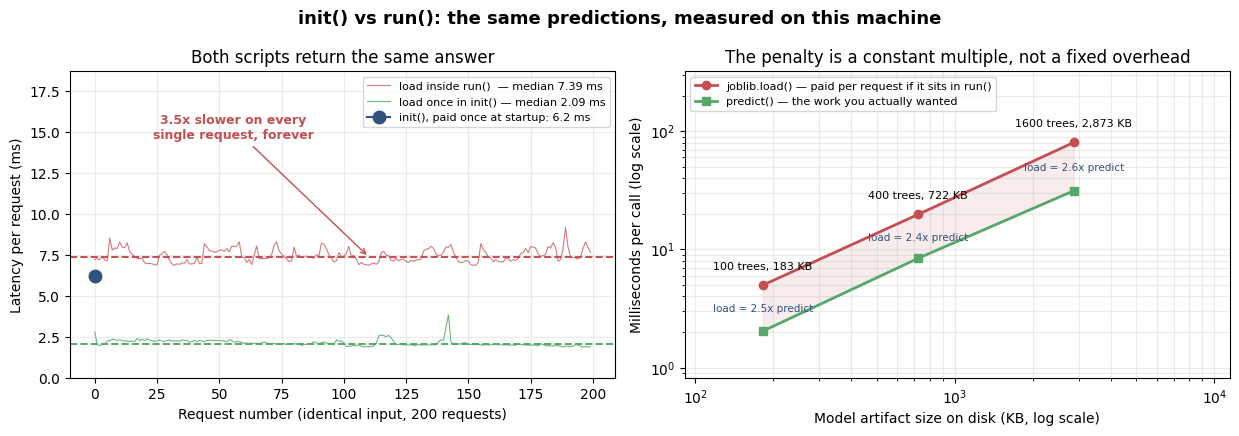

init() cost, paid once            : 6.2 ms
run() with the model already loaded: 2.09 ms (median of 200)
run() reloading the model each time: 7.39 ms (median of 200)
Penalty                            : 3.5x per request, 1.06 s wasted over 200 requests
Artifact load time: 5.0 ms at 183 KB -> 80.4 ms at 2,873 KB
load / predict ratio at each size: 2.5x, 2.4x, 2.6x


In [5]:
# WHAT: time two versions of the scoring contract — model loaded once in init()
# vs reloaded inside every run() — and then time model loading against artifact size.
# WHY: the init()/run() split is a performance contract, and a wrong version of it
# is invisible in the response body. It is only visible in the clock.
import time
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

N_REQUESTS = 200
one_flower = X_test[:1]              # the same single request, every time

# --- Pattern 1 (correct): load once, the way init() does ---------------------
t0 = time.perf_counter()
m_once = joblib.load(model_dir / 'model.joblib')
s_once = joblib.load(model_dir / 'scaler.joblib')
init_ms = (time.perf_counter() - t0) * 1000

warm_ms = []
for _ in range(N_REQUESTS):
    t = time.perf_counter()
    m_once.predict(s_once.transform(one_flower))
    warm_ms.append((time.perf_counter() - t) * 1000)

# --- Pattern 2 (the bug): load inside run(), on every request ----------------
cold_ms = []
for _ in range(N_REQUESTS):
    t = time.perf_counter()
    m_each = joblib.load(model_dir / 'model.joblib')
    s_each = joblib.load(model_dir / 'scaler.joblib')
    m_each.predict(s_each.transform(one_flower))
    cold_ms.append((time.perf_counter() - t) * 1000)

warm_med, cold_med = float(np.median(warm_ms)), float(np.median(cold_ms))

# --- How the load cost grows with the artifact ------------------------------
# Real measurements, not an extrapolation: the same forest at three sizes.
sizes_kb, load_ms, pred_ms = [], [], []
for n_trees in (100, 400, 1600):
    f = RandomForestClassifier(n_estimators=n_trees, random_state=42).fit(X_train_s, y_train)
    p = model_dir / f'sizing_{n_trees}.joblib'
    joblib.dump(f, p)
    sizes_kb.append(p.stat().st_size / 1024)
    # Best of five loads, so one unlucky disk read does not set the number.
    trials = []
    for _ in range(5):
        t = time.perf_counter()
        joblib.load(p)
        trials.append((time.perf_counter() - t) * 1000)
    load_ms.append(min(trials))
    t = time.perf_counter()
    for _ in range(20):
        f.predict(scaler.transform(one_flower))
    pred_ms.append((time.perf_counter() - t) * 1000 / 20)
    p.unlink()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

# --- Left: per-request latency, the two scoring scripts ---------------------
ax = axes[0]
ax.plot(cold_ms, color='#C44E52', lw=0.8, alpha=0.75,
        label=f'load inside run()  — median {cold_med:.2f} ms')
ax.plot(warm_ms, color='#55A868', lw=0.8, alpha=0.85,
        label=f'load once in init() — median {warm_med:.2f} ms')
ax.axhline(cold_med, color='#C44E52', ls='--', lw=1.4)
ax.axhline(warm_med, color='#55A868', ls='--', lw=1.4)
ax.plot([0], [init_ms], marker='o', ms=9, color='#31527d',
        label=f'init(), paid once at startup: {init_ms:.1f} ms')
# Anchor the label in AXES coordinates: init_ms varies between machines, so a
# data-coordinate y could land outside the axes and print over the title.
ax.annotate(f'{cold_med / warm_med:.1f}x slower on every\nsingle request, forever',
            xy=(N_REQUESTS * 0.55, cold_med), xycoords='data',
            xytext=(0.30, 0.78), textcoords='axes fraction',
            fontsize=9, color='#C44E52', fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color='#C44E52'))
ax.set_xlabel(f'Request number (identical input, {N_REQUESTS} requests)')
ax.set_ylabel('Latency per request (ms)')
ax.set_title('Both scripts return the same answer')
ax.set_ylim(0, max(init_ms, max(cold_ms[3:]), cold_med * 2.2) * 1.15)  # keep the init() dot and the label on the axes
ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.25)

# --- Right: and the gap is a function of how big the model is ---------------
ax = axes[1]
ax.plot(sizes_kb, load_ms, marker='o', color='#C44E52', lw=2,
        label='joblib.load() — paid per request if it sits in run()')
ax.plot(sizes_kb, pred_ms, marker='s', color='#55A868', lw=2,
        label='predict() — the work you actually wanted')
# Both costs grow with the model; what matters is that the red line stays a
# roughly constant multiple above the green one at every size.
ax.fill_between(sizes_kb, pred_ms, load_ms, color='#C44E52', alpha=0.10)
for x, yl, yp, n in zip(sizes_kb, load_ms, pred_ms, (100, 400, 1600)):
    ax.annotate(f'{n} trees, {x:,.0f} KB', xy=(x, yl), xytext=(0, 11),
                textcoords='offset points', ha='center', fontsize=8)
    ax.annotate(f'load = {yl / yp:.1f}x predict', xy=(x, (yl * yp) ** 0.5), xytext=(0, -3),
                textcoords='offset points', ha='center', fontsize=7.5, color='#31527d')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Model artifact size on disk (KB, log scale)')
ax.set_ylabel('Milliseconds per call (log scale)')
ax.set_title('The penalty is a constant multiple, not a fixed overhead')
ax.set_ylim(min(pred_ms) * 0.4, max(load_ms) * 4)
ax.set_xlim(sizes_kb[0] * 0.5, sizes_kb[-1] * 4)  # room for the point labels
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.25, which='both')

fig.suptitle('init() vs run(): the same predictions, measured on this machine',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"init() cost, paid once            : {init_ms:.1f} ms")
print(f"run() with the model already loaded: {warm_med:.2f} ms (median of {N_REQUESTS})")
print(f"run() reloading the model each time: {cold_med:.2f} ms (median of {N_REQUESTS})")
print(f"Penalty                            : {cold_med / warm_med:.1f}x per request, "
      f"{(cold_med - warm_med) * N_REQUESTS / 1000:.2f} s wasted over {N_REQUESTS} requests")
print(f"Artifact load time: {load_ms[0]:.1f} ms at {sizes_kb[0]:,.0f} KB "
      f"-> {load_ms[-1]:.1f} ms at {sizes_kb[-1]:,.0f} KB")
print("load / predict ratio at each size: " +
      ", ".join(f"{l / p:.1f}x" for l, p in zip(load_ms, pred_ms)))


**🔍 Read the figure.** *Left:* two `score.py` files that return **identical predictions**, timed over 200 identical requests. The green line is the contract as written — `init()` loads the model once (the blue dot at request 0) and `run()` only predicts. The red line loads the model inside `run()`. The two dashed medians never cross: the red one sits above the green one on **every request, for the life of the container**, and the multiplier is printed on the plot and in the cell output. Nothing in the JSON response would ever tell you which script you deployed.

*Right:* why this does not amortise away on a bigger model. Both axes are log. As the same forest grows from 100 to 1,600 trees (183 KB to 2.8 MB), **both** costs rise — but the red `joblib.load()` line stays a roughly **constant multiple above** the green `predict()` line at every size, and each point is labelled with that ratio. So moving the load into `run()` does not add a fixed overhead you outgrow; it multiplies the cost of every request, at every model size. A real transformer artifact is measured in hundreds of megabytes rather than kilobytes, and the multiplier does not care. That is the whole reason Azure ML calls `init()` exactly once and `run()` for every request.

## 5. Connect to an Azure ML Workspace

In [6]:
# Connect to Azure ML — or fall back honestly when this machine has no credentials.
# Quiet the azure.identity logger first: on a machine without credentials it
# writes a 20-line diagnostic wall to stderr for the failed token attempt —
# our except-branch already explains the failure in two honest lines.
import logging
logging.getLogger("azure.identity").setLevel(logging.CRITICAL)

try:
    from azure.ai.ml import MLClient
    from azure.identity import DefaultAzureCredential

    SUBSCRIPTION_ID = 'your-subscription-id'
    RESOURCE_GROUP = 'my-ml-resource-group'
    WORKSPACE_NAME = 'my-ml-workspace'

    credential = DefaultAzureCredential()

    # DefaultAzureCredential authenticates LAZILY: constructing MLClient never
    # contacts Azure, so it "succeeds" even with zero credentials. Force a real
    # token request NOW so this cell reports the truth about this environment —
    # without this line, "Connected" would print on machines that are not
    # connected at all, and every later cell would crash instead of falling back.
    credential.get_token("https://management.azure.com/.default")

    ml_client = MLClient(
        credential=credential,
        subscription_id=SUBSCRIPTION_ID,
        resource_group_name=RESOURCE_GROUP,
        workspace_name=WORKSPACE_NAME,
    )
    print(f"Connected to workspace: {ml_client.workspace_name}")

except Exception as e:
    # No usable credentials: record that fact and let every later cell take its
    # "[No client] Would call ..." teaching path instead of raising.
    ml_client = None
    print(f"[Auth error - expected in local environment] {type(e).__name__}")
    print()
    print("DefaultAzureCredential auth order:")
    methods = [
        'Environment variables (AZURE_CLIENT_ID, AZURE_TENANT_ID, AZURE_CLIENT_SECRET)',
        'Managed Identity (works inside Azure VMs, App Service, AKS)',
        'Azure CLI token (run: az login)',
        'Visual Studio Code extension token',
        'Interactive browser login',
    ]
    for i, method in enumerate(methods, 1):
        print(f"  {i}. {method}")


[Auth error - expected in local environment] ClientAuthenticationError

DefaultAzureCredential auth order:
  1. Environment variables (AZURE_CLIENT_ID, AZURE_TENANT_ID, AZURE_CLIENT_SECRET)
  2. Managed Identity (works inside Azure VMs, App Service, AKS)
  3. Azure CLI token (run: az login)
  4. Visual Studio Code extension token
  5. Interactive browser login


## 6. Register the Model

In [7]:
# WHAT: register the model directory as a versioned Model asset in the workspace.
# WHY: registration is what makes deployments reproducible — 'azureml:iris-
# classifier:1' is a permanent address other steps can reference.
try:
    from azure.ai.ml.entities import Model
    from azure.ai.ml.constants import AssetTypes

    model_asset = Model(
        path='/tmp/azure_model',
        type=AssetTypes.CUSTOM_MODEL,
        name='iris-classifier',
        version='1',
        description='Random Forest iris classifier with StandardScaler',
    )

    # With no workspace connection, print the registration we WOULD send.
    if ml_client:
        registered_model = ml_client.models.create_or_update(model_asset)
        print(f"Model registered: {registered_model.name} v{registered_model.version}")
    else:
        print("[No client] Would call: ml_client.models.create_or_update(model_asset)")
        print("Model config:")
        print(f"  name    : {model_asset.name}")
        print(f"  version : {model_asset.version}")
        print(f"  path    : {model_asset.path}")
        print(f"  type    : {model_asset.type}")

except Exception as e:
    print(f"[Error] {type(e).__name__}: {e}")

[No client] Would call: ml_client.models.create_or_update(model_asset)
Model config:
  name    : iris-classifier
  version : 1
  path    : /tmp/azure_model
  type    : custom_model


## 7. Create an Online Endpoint

In [8]:
# WHAT: create the managed online endpoint — the stable URL + auth wrapper.
# WHY: in Azure the endpoint (address) and deployment (compute running a model
# version) are separate objects; this cell creates only the address.
ENDPOINT_NAME = 'iris-endpoint-aiat125'

try:
    from azure.ai.ml.entities import ManagedOnlineEndpoint

    endpoint = ManagedOnlineEndpoint(
        name=ENDPOINT_NAME,
        description='Iris species classifier endpoint',
        auth_mode='key',   # 'key' = static API key auth
        tags={'course': 'AIAT125', 'model': 'iris-rf'},
    )

    # begin_* calls are async pollers — .result() blocks until Azure finishes.
    if ml_client:
        poller = ml_client.online_endpoints.begin_create_or_update(endpoint)
        result = poller.result()  # blocks until done (~2 min)
        print(f"Endpoint created: {result.scoring_uri}")
    else:
        print("[No client] Would call: ml_client.online_endpoints.begin_create_or_update(endpoint)")
        print(f"  name      : {ENDPOINT_NAME}")
        print(f"  auth_mode : key (requests must include the endpoint API key)")
        print(f"  scoring URI would be: https://{ENDPOINT_NAME}.eastus.inference.ml.azure.com/score")

except Exception as e:
    print(f"[Error] {type(e).__name__}: {e}")

[No client] Would call: ml_client.online_endpoints.begin_create_or_update(endpoint)
  name      : iris-endpoint-aiat125
  auth_mode : key (requests must include the endpoint API key)
  scoring URI would be: https://iris-endpoint-aiat125.eastus.inference.ml.azure.com/score


## 8. Create a Deployment and Route Traffic

In [9]:
# WHAT: create the 'blue' deployment under the endpoint and give it 100% traffic.
# WHY: named deployments are the unit of rollout — later a 'green' deployment
# can take 10% traffic for a safe A/B test before full cutover.
try:
    from azure.ai.ml.entities import ManagedOnlineDeployment, CodeConfiguration

    deployment = ManagedOnlineDeployment(
        name='blue',
        endpoint_name=ENDPOINT_NAME,
        model='azureml:iris-classifier:1',      # references the registered model
        code_configuration=CodeConfiguration(
            code='/tmp/azure_model',
            scoring_script='score.py',
        ),
        environment='azureml:AzureML-sklearn-1.0-ubuntu20.04-py38-cpu:33',
        instance_type='Standard_DS2_v2',  # 2 vCPU, 7 GB RAM
        instance_count=1,
    )

    # Two steps: provision the deployment, then flip the endpoint's traffic map.
    if ml_client:
        poller = ml_client.online_deployments.begin_create_or_update(deployment)
        poller.result()
        # Route 100% of traffic to the blue deployment
        endpoint_obj = ml_client.online_endpoints.get(ENDPOINT_NAME)
        endpoint_obj.traffic = {'blue': 100}
        ml_client.online_endpoints.begin_create_or_update(endpoint_obj).result()
        print("Deployment created and 100% traffic routed to 'blue'.")
    else:
        print("[No client] Would call: ml_client.online_deployments.begin_create_or_update(deployment)")
        print("Deployment config:")
        print(f"  name           : blue")
        print(f"  instance_type  : Standard_DS2_v2")
        print(f"  instance_count : 1")
        print(f"  scoring_script : score.py")
        print()
        print("A/B test traffic split example:")
        print("  endpoint.traffic = {'blue': 90, 'green': 10}")
        print("  ml_client.online_endpoints.begin_create_or_update(endpoint)")

except Exception as e:
    print(f"[Error] {type(e).__name__}: {e}")

[No client] Would call: ml_client.online_deployments.begin_create_or_update(deployment)
Deployment config:
  name           : blue
  instance_type  : Standard_DS2_v2
  instance_count : 1
  scoring_script : score.py

A/B test traffic split example:
  endpoint.traffic = {'blue': 90, 'green': 10}
  ml_client.online_endpoints.begin_create_or_update(endpoint)


## 9. Invoke the Endpoint

In [10]:
# WHAT: invoke the endpoint with two flowers — or simulate the response locally.
# WHY: the invoke call is what clients do in production; the local simulation
# shows the exact response shape without needing a live endpoint.
import json

test_payload = json.dumps({'data': [[5.1, 3.5, 1.4, 0.2], [6.7, 3.1, 4.7, 1.5]]})

try:
    # Fallback below reproduces the scoring path with the local model artifacts.
    if ml_client:
        response = ml_client.online_endpoints.invoke(
            endpoint_name=ENDPOINT_NAME,
            deployment_name='blue',
            body=test_payload,
        )
        print(f"Response: {response}")
    else:
        print("[No client] Would call: ml_client.online_endpoints.invoke(...)")
        print(f"Input: {test_payload}")
        print()
        # Simulate using local model
        data = json.loads(test_payload)
        features = np.array(data['data'])
        features_s = scaler.transform(features)
        preds = clf.predict(features_s)
        probs = clf.predict_proba(features_s).max(axis=1)
        simulated = {
            'predictions': [iris.target_names[p] for p in preds],
            'confidence': [round(float(p), 3) for p in probs]
        }
        print(f"Simulated response: {json.dumps(simulated, indent=2)}")

except Exception as e:
    print(f"[Error] {type(e).__name__}: {e}")

[No client] Would call: ml_client.online_endpoints.invoke(...)
Input: {"data": [[5.1, 3.5, 1.4, 0.2], [6.7, 3.1, 4.7, 1.5]]}

Simulated response: {
  "predictions": [
    "setosa",
    "versicolor"
  ],
  "confidence": [
    1.0,
    1.0
  ]
}


### Walking the traffic split from blue to green

Section 8 printed `endpoint.traffic = {'blue': 90, 'green': 10}` as one line of configuration. A rollout is a *sequence* of those lines, and the only reason to run one is to measure something. So the cell below builds a real `green` candidate — the same random forest trained on the two sepal features only, the kind of model that passes a smoke test and is genuinely worse — scores both models on the same held-out flowers, and walks the split from 100/0 to 0/100.

Measured on the same 30 held-out flowers:
  blue  (4 features) accuracy: 1.000
  green (2 features) accuracy: 0.767

    stage                traffic  blended acc  green slice
  initial {'blue': 100, 'green': 0}        1.000 n/a (no green traffic)
   canary {'blue': 90, 'green': 10}        0.977        0.767
     half {'blue': 50, 'green': 50}        0.883        0.767
 majority {'blue': 10, 'green': 90}        0.790        0.767
  cutover {'blue': 0, 'green': 100}        0.767        0.767


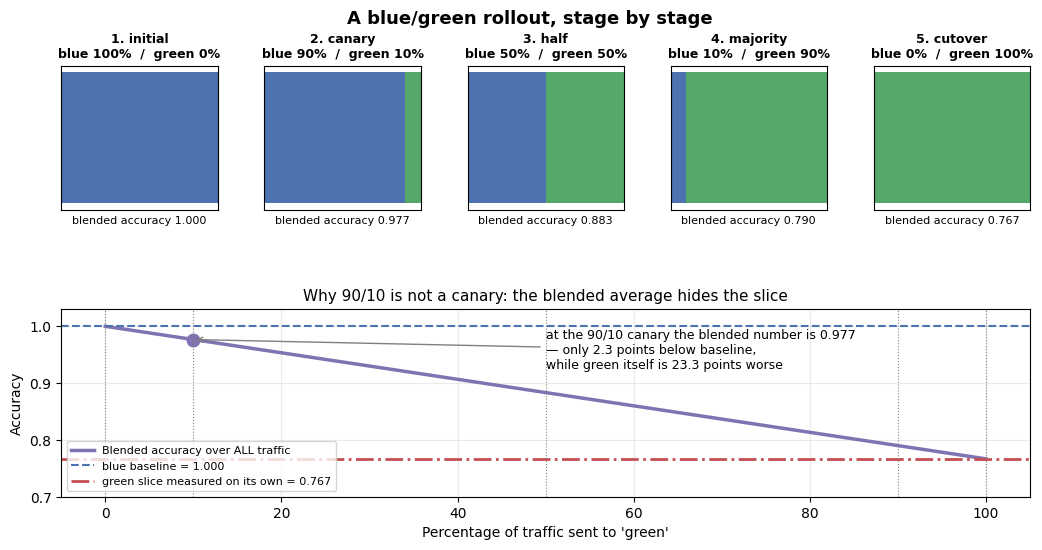

In [11]:
# WHAT: build a real 'green' candidate, measure both models on the same held-out
# set, and walk the traffic split from 100/0 to 0/100 as a storyboard.
# WHY: a traffic split is a sequence of states, and the number a dashboard shows
# (the blended average) behaves very differently from the number that matters
# (the green slice on its own).
import numpy as np
import matplotlib.pyplot as plt

# 'green' is a real candidate, not a hypothetical: the same forest trained on the
# two sepal features only — the kind of model that passes a smoke test and is
# genuinely worse.
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaler_green = StandardScaler().fit(X_train[:, :2])
clf_green = RandomForestClassifier(n_estimators=100, random_state=42)
clf_green.fit(scaler_green.transform(X_train[:, :2]), y_train)

acc_blue  = clf.score(scaler.transform(X_test), y_test)
acc_green = clf_green.score(scaler_green.transform(X_test[:, :2]), y_test)
print(f"Measured on the same {len(y_test)} held-out flowers:")
print(f"  blue  (4 features) accuracy: {acc_blue:.3f}")
print(f"  green (2 features) accuracy: {acc_green:.3f}\n")

# The rollout as endpoint.traffic dictionaries — the exact object section 8 sets.
stages = [
    ("initial",  {'blue': 100, 'green': 0}),
    ("canary",   {'blue': 90,  'green': 10}),
    ("half",     {'blue': 50,  'green': 50}),
    ("majority", {'blue': 10,  'green': 90}),
    ("cutover",  {'blue': 0,   'green': 100}),
]

print(f"{'stage':>9} {'traffic':>22} {'blended acc':>12} {'green slice':>12}")
rows = []
for name, traffic in stages:
    w = traffic['green'] / 100.0
    blended = (1 - w) * acc_blue + w * acc_green
    slice_acc = acc_green if traffic['green'] > 0 else float('nan')
    rows.append((name, traffic, blended, slice_acc))
    shown = 'n/a (no green traffic)' if traffic['green'] == 0 else f"{slice_acc:.3f}"
    print(f"{name:>9} {str(traffic):>22} {blended:12.3f} {shown:>12}")

fig = plt.figure(figsize=(12.5, 5.6))
gs = fig.add_gridspec(2, 5, height_ratios=[1, 1.3], hspace=0.6, wspace=0.3)

# --- storyboard: one frame per traffic split ------------------------------
for k, (name, traffic, blended, slice_acc) in enumerate(rows):
    ax = fig.add_subplot(gs[0, k])
    ax.barh([0], [traffic['blue']], color='#4C72B0', label='blue')
    ax.barh([0], [traffic['green']], left=[traffic['blue']], color='#55A868', label='green')
    ax.set_xlim(0, 100)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(f"{k+1}. {name}\nblue {traffic['blue']}%  /  green {traffic['green']}%",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel(f"blended accuracy {blended:.3f}", fontsize=8)

# --- what the two numbers do as green's share grows -----------------------
ax = fig.add_subplot(gs[1, :])
shares = np.arange(0, 101)
blended_curve = (1 - shares / 100) * acc_blue + (shares / 100) * acc_green
ax.plot(shares, blended_curve, color='#8172B2', lw=2.5, label='Blended accuracy over ALL traffic')
ax.axhline(acc_blue, color='#4C72B0', ls='--', lw=1.5, label=f'blue baseline = {acc_blue:.3f}')
ax.axhline(acc_green, color='#C44E52', ls='-.', lw=2,
           label=f'green slice measured on its own = {acc_green:.3f}')
canary = 10
ax.plot([canary], [blended_curve[canary]], 'o', color='#8172B2', ms=9)
ax.annotate(f"at the 90/10 canary the blended number is {blended_curve[canary]:.3f}\n"
            f"— only {100*(acc_blue-blended_curve[canary]):.1f} points below baseline,\n"
            f"while green itself is {100*(acc_blue-acc_green):.1f} points worse",
            xy=(canary, blended_curve[canary]), xytext=(50, 0.925), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='gray'))
for k, (name, traffic, blended, _s) in enumerate(rows):
    ax.axvline(traffic['green'], color='gray', ls=':', lw=0.8)
ax.set_xlabel("Percentage of traffic sent to 'green'")
ax.set_ylabel('Accuracy')
ax.set_ylim(0.70, 1.03)
ax.set_title('Why 90/10 is not a canary: the blended average hides the slice', fontsize=11)
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.25)

fig.suptitle('A blue/green rollout, stage by stage', fontsize=13, fontweight='bold')
plt.show()


**🔍 Read the figure.** *Top row:* five states of the same endpoint, with the number a dashboard averaging all traffic would report printed under each one. *Bottom panel:* the purple line is that blended number as green's share grows. The blue dashed line is blue's real accuracy on these 30 held-out flowers (**1.000**); the red dash-dot line is green's real accuracy measured on its own (**0.767**).

Now find the canary. At **90/10** the blended number is **0.977** — the overall metric moved **2.3 points** while the model behind the canary is **23.3 points worse**. Ten percent of traffic dilutes a bad model by a factor of ten, which is exactly how a blended dashboard passes a deployment that is unfit to take the other ninety percent. The blended line only reaches the truth at 100% green, which is far too late to learn it. Compute the green slice on its own, against the blue baseline, or the split has told you nothing — and note that with a slice this small you also need enough requests in it for the number to mean anything, which is the statistics half of the problem (Unit 5, notebook 07).

## 💬 Discuss

The scoring script ran locally and returned `setosa` and `versicolor` at confidence **1.0** — the same answers the endpoint would return, because `init()` and `run()` are the same functions Azure ML calls in the container.

1. We tested `score.py` by importing it and calling `init()` then `run()`. Name two things that will differ inside the managed container and could break a script that passes this test. Which of them would you catch with a better local test, and which only with a real deployment?
2. `endpoint.traffic = {'blue': 90, 'green': 10}` sends a tenth of users to a new model. Given Booking.com's finding above, what would you measure on that 10% — and how long would you have to wait before the number means anything? (Unit 5, notebook 07 does the statistics; here, argue the design.)
3. `DefaultAzureCredential` tries five authentication methods in order and picks the first that works. That is convenient in development. Argue whether it is a good idea in production, where "whichever identity happened to be available" decides what your job can access.

## 10. Clean Up

In [12]:
# WHAT: delete the endpoint (which stops the billed compute behind it).
# WHY: managed endpoints bill continuously — cleanup is part of the deployment
# workflow, not an afterthought; note the delete order in the printout.
try:
    if ml_client:
        ml_client.online_endpoints.begin_delete(name=ENDPOINT_NAME).result()
        print(f"Endpoint '{ENDPOINT_NAME}' deleted.")
    else:
        print("[No client] Would call: ml_client.online_endpoints.begin_delete(name=ENDPOINT_NAME)")
        print()
        print("Cleanup order:")
        print("  1. Delete deployment  -- stops billing for compute instances")
        print("  2. Delete endpoint    -- removes the DNS/URL")
        print("  3. Optionally delete the registered model version")

except Exception as e:
    print(f"[Error] {type(e).__name__}: {e}")

[No client] Would call: ml_client.online_endpoints.begin_delete(name=ENDPOINT_NAME)

Cleanup order:
  1. Delete deployment  -- stops billing for compute instances
  2. Delete endpoint    -- removes the DNS/URL
  3. Optionally delete the registered model version


## Summary

The Azure ML online endpoint deployment flow:
1. **Train & save** the model locally
2. **Write a scoring script** with `init()` and `run()` — Azure ML calls these functions
3. **Register the model** in the Azure ML model registry (`ml_client.models.create_or_update`)
4. **Create an online endpoint** — the stable HTTPS URL
5. **Create a deployment** — specifies instance type, model version, scoring script
6. **Route traffic** — assign percentages to deployments (enables A/B testing)
7. **Delete** when done to stop billing

Key Azure ML vocabulary:
- **Endpoint** = the URL (stable, does not change when you update the model)
- **Deployment** = the running infrastructure behind the endpoint (changes when you update)

## Self-Check

1. **What is the scoring script in Azure ML?**
   *(What two functions must it define, and when is each called?)*

2. **What does `DefaultAzureCredential` try in order to authenticate?**
   *(List at least three methods it attempts, in order.)*

3. **How is an Azure ML 'deployment' different from an 'endpoint'?**
   *(Which one changes when you push a new model version? Which stays the same?)*

## ⚠️ Where this breaks

- **A traffic split measures what you instrument, not what matters.** Sending 10% of traffic to `green` produces evidence only if you are logging an outcome you can compare — a conversion, a correction, a downstream label. Booking.com's point is precisely that accuracy on held-out data was the wrong thing to look at. Decide the metric before you split the traffic.
- **90/10 is not a canary.** A blended average is dominated by the 90%: a bad `green` deployment barely moves it. You must evaluate the **green slice on its own** against the blue baseline, which is a different computation from "did overall accuracy drop" (Unit 5, notebook 07 shows the honest version).
- **Deleting the endpoint is not the same as stopping the bill.** The compute lives in the *deployment*. Delete the deployment to stop instance charges; delete the endpoint to release the URL. Getting that order wrong leaves you paying for a DNS name's worth of idle VMs.
- **The assumption that must hold:** the environment inside the managed container can import everything `score.py` needs. Azure ML builds that environment from your specification, not from your laptop. A missing dependency does not appear until the deployment rolls out, minutes later, as an unhealthy container.
- **Everything here ran without credentials.** The auth error printed above is real, and every subsequent call is a description of what would be sent. You have not seen a deployment take ten minutes, or a scoring script fail inside a container. This is the map.
- **The cheaper alternative.** If you are not on Microsoft's stack, do not adopt Azure ML for the endpoint/deployment pattern alone — Unit 4's Docker image plus a Kubernetes Deployment gives you the same swap-behind-a-stable-address property with no platform SDK in your inference code. Azure ML earns its place with the registry, Active Directory integration and native MLflow support, which is a different reason.

## 📚 References

1. Amershi, S., Begel, A., Bird, C., et al. (2019). *Software Engineering for Machine Learning: A Case Study*. ICSE-SEIP. <https://www.microsoft.com/en-us/research/publication/software-engineering-for-machine-learning-a-case-study/>
2. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2022). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access. <https://arxiv.org/abs/2205.02302>
4. Park, S., Jeon, S., Lee, C., Jeon, S., Kim, B.-S., & Lee, J. (2025). *A Survey on Inference Engines for Large Language Models: Perspectives on Optimization and Efficiency*. arXiv. <https://arxiv.org/abs/2505.01658>
5. Ghosh, A., Reuel, A., Chim, J., et al. (2026). *Evaluation Cards: An Interpretive Layer for AI Evaluation Reporting*. arXiv. <https://arxiv.org/abs/2606.09809>
